In [1]:
# Import necessary libraries
import csv
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd

import scanpy as sc
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
from model.model import MIL, EarlyStopping


In [34]:
from torch.utils.data import Dataset
import pandas as pd
import scanpy as sc
import numpy as np
import torch
import scipy.sparse as sp
from scipy.spatial.distance import cdist
from tqdm import trange
from scipy.sparse import issparse


def preprocess_data(adata, immune_cell, n_genes, resolution):
    # Read the data
    
    if immune_cell not in adata.obs.columns:
        immune_cell = map_immune_cell(immune_cell)
        
    # Ensure adata is not a view
    adata = adata.copy()
    adata.var_names_make_unique()  # Ensure unique gene names

    # Filter the tumor cells
    print(adata.obs['cell_type'].unique())
    tumor_cells = adata[adata.obs['cell_type'].astype(int) == 1].copy()

    # Debug: Check tumor cells
    print(f"Tumor cells shape after filtering: {tumor_cells.shape}")
    if tumor_cells.shape[0] == 0:
        print("Warning: No tumor cells found after filtering.")

    # Calculate mean expression
    if issparse(tumor_cells.X):
        # Convert to dense and compute mean expression
        mean_expression = np.asarray(tumor_cells.X.mean(axis=0)).ravel()
    else:
        mean_expression = tumor_cells.X.mean(axis=0)

    # Get gene names
    gene_names = tumor_cells.var_names

    # Select top n genes
    print(f"Selecting top {n_genes} genes based on mean expression")
    if n_genes > len(gene_names):
        n_genes = int(len(gene_names) * 0.2)
    top_n_gene_indices = mean_expression.argsort()[-n_genes:][::-1]
    top_n_gene_names = gene_names[top_n_gene_indices]

    tumor_genes = [
        # possible tumor antigens or genes that promote tumor antigen presentation
        'TAP2','IFI6','TOP2A','PBK','TPX2','PRAME','MUC1','MUC12','CEACAM1','EPCAM','PMEL','MLANA','LAGE3','HORMAD1',
        'CTAG1B','KRT8','KRT18','KRT19','ERBB2','MAGEA3','MAGEA4','MAGEA10','AFP','CEACAM5','SOX2','SLC45A2','WT1','HOXB9','GUCY2C',
        # genes that are usually highly up-regulated in tumor cells but are unlikely to be tumor antigens
        'MYC','CCND1','CDK4','CDK6','AURKA','BCL2','BIRC5','MCL1','CD274','FGL1','MMP2','MMP9','VEGFA',
        'TWIST1','VEGF','ANGPT2','HIF1A','HK2','LDHA','SLC2A1','PARP1','RAD51','VIM','SNAI1','ALDH1A1',
        'NANOG','EGFR','KIT','CXCL8','STAT3','KRAS','TP53'
        # B cell antigen genes from Jose and Shirley
        'OR2H1','SDCBP','OR5V1','GPR85','OR2H1','SDCBP','TSPAN31','TMEM191C','IGSF8'
    ]
    
    hla_genes = list(adata.var_names[adata.var_names.str.startswith("HLA")])    
    select_genes=tumor_genes+hla_genes+list(top_n_gene_names)
    existing_genes = [gene for gene in select_genes if gene in adata.var_names]

    genes_to_exclude=["CD68","STAT1","MMP13","EPDR1","CLCA1","FBLN1","C9orf16","ADGRF1","LINGO2"]
    existing_genes = [gene for gene in existing_genes if gene not in genes_to_exclude]
    
    # Subset adata using gene names to keep indices consistent
    adata = adata[:, existing_genes].copy()

    adata.obs[immune_cell] = adata.obs[immune_cell].astype(float)
    tumor_cells.obs[immune_cell] = tumor_cells.obs[immune_cell].astype(float)

    # Binarize the immune cell column based on the percentile value if resolution is not 'high'
    if resolution != 'high':
        if tumor_cells.obs[immune_cell].empty:
            print(f"Error: tumor_cells.obs[{immune_cell}] is empty.")
        else:
            unique_values = tumor_cells.obs[immune_cell].unique()
            if set(unique_values).issubset({0, 1}):
                print(f"tumor_cells.obs[{immune_cell}] is already binary. Skipping binarization.")
            else:
                percentile_value = np.percentile(tumor_cells.obs[immune_cell], 75)
                print(f"Percentile value: {percentile_value}")
                adata.obs[immune_cell] = np.where(adata.obs[immune_cell] > percentile_value, 1, 0)
                print(f"adata.obs[{immune_cell}] after binarization: {adata.obs[immune_cell].head()}")

    return adata


class BagsDataset(Dataset):
    def __init__(self, input_data, immune_cell, max_instances=None, radius=200, resolution='low', n_genes=500, k=2):
        self.immune_cell = map_immune_cell(immune_cell)
        print(f"Immune cell: {self.immune_cell}")
        self.max_instances = max_instances
        self.radius = radius
        self.resolution = resolution
        self.n_genes = n_genes
        self.k = k  # Number of bags per batch
        if isinstance(input_data, str):
            self.batches = self.create_bags_from_csv(input_data)
        elif isinstance(input_data, sc.AnnData):
            input_data = preprocess_data(input_data, immune_cell, n_genes, self.resolution)
            print(f"Preprocessed data: {input_data.X.shape}")
            self.batches = self.create_bags_from_adata(input_data)
        else:
            raise ValueError("input_data must be either a path to a CSV file or an AnnData object")

    def __len__(self):
        return len(self.batches)

    def __getitem__(self, idx):
        batch = self.batches[idx]
        # batch is a list of bags
        batch_data = []
        for bag in batch:
            distances = bag['distances']
            gene_expression = bag['gene_expression']
            label = bag['label']
            core_idx = bag['core_idx']
            gene_names = bag['gene_names']
            cell_id = bag['cell_id']
            bag_dict = {
                'distances': distances,
                'gene_expression': gene_expression,
                'label': label,
                'core_idx': core_idx,
                'gene_names': gene_names,
                'cell_id': cell_id
            }
            batch_data.append(bag_dict)
        return batch_data

    def create_bags_from_csv(self, csv_file):
        data = pd.read_csv(csv_file)
        adata_radius_list = []
        for _, row in data.iterrows():
            adata_path = row['adata']
            print(f"Reading adata from {adata_path}")
            resolution = row['resolution'] if 'resolution' in row and not pd.isna(row['resolution']) else self.resolution
            adata = sc.read_h5ad(adata_path)
            adata.obs_names_make_unique()
            adata = preprocess_data(adata, self.immune_cell, self.n_genes, resolution=resolution)
            radius = row['radius'] if 'radius' in row and not pd.isna(row['radius']) else self.radius
            adata_radius_list.append((adata, radius, resolution))
            print(f"Processing: adata={adata_path.split('/')[-1]}, radius={radius}, resolution={resolution}")
        return self.create_bags(adata_radius_list)

    def create_bags_from_adata(self, adata):
        adata_radius_list = [(adata, self.radius, self.resolution)]
        return self.create_bags(adata_radius_list)

    def create_bags(self, adata_radius_list):
        all_batches = []
        for adata, radius, resolution in adata_radius_list:
            # Collect positive and negative bags per adata
            positive_bags = []
            negative_bags = []
            spatial_coords_x = adata.obs['X'].astype(float)
            spatial_coords_y = adata.obs['Y'].astype(float)
            spatial_coords = np.array(list(zip(spatial_coords_x, spatial_coords_y)))
            gene_expression = adata.X
            labels = adata.obs[self.immune_cell].values.astype(int)  
            adata.obs['cell_type'] = adata.obs['cell_type'].astype(int)
            cell_types = adata.obs['cell_type'].values
            barcodes = adata.obs.index.values  
            gene_names = adata.var_names.tolist()

            for i in trange(len(spatial_coords), desc=f"Creating Bags with radius {radius}", ncols=100):
                if cell_types[i] == 0:
                    continue
                dist_matrix_row = cdist([spatial_coords[i]], spatial_coords, metric='euclidean')[0]
                in_circle = np.where(dist_matrix_row <= radius)[0]
                in_circle = [idx for idx in in_circle if cell_types[idx] == 1]
                num_tumor_cells = len(in_circle)
                if resolution == 'high' and num_tumor_cells < 10:
                    continue
                if resolution == 'high':
                    in_circle = [idx for idx in in_circle if idx != i]
                if len(in_circle) == 0:
                    continue
                if self.max_instances is not None and len(in_circle) > self.max_instances:
                    continue

                gene_data = gene_expression[in_circle]
                distances = np.asmatrix(dist_matrix_row[in_circle].reshape(-1, 1), dtype=np.float32)

                bag = {
                    'distances': distances,
                    'gene_expression': gene_data,
                    'label': labels[i],
                    'core_idx': i,
                    'gene_names': gene_names,
                    'cell_id': barcodes[i]
                }

                if labels[i] == 1:
                    positive_bags.append(bag)
                else:
                    negative_bags.append(bag)

            num_negative_per_batch = self.k - 1
            if len(negative_bags) < num_negative_per_batch:
                print(f"Not enough negative bags in this adata to create batches. Dropping extra positive bags.")
                num_batches = len(negative_bags) // num_negative_per_batch
                if num_batches == 0:
                    continue 
                if len(positive_bags) > num_batches:
                    positive_bags = positive_bags[:num_batches]
            else:
                num_batches = min(len(positive_bags), len(negative_bags) // num_negative_per_batch)
                if len(positive_bags) > num_batches:
                    positive_bags = positive_bags[:num_batches]
                if len(negative_bags) > num_batches * num_negative_per_batch:
                    negative_bags = negative_bags[:num_batches * num_negative_per_batch]
        
            np.random.shuffle(negative_bags)

            for i in range(num_batches):
                batch = [positive_bags[i]] + negative_bags[i * num_negative_per_batch: (i + 1) * num_negative_per_batch]
                all_batches.append(batch)

        total_batches = len(all_batches)
        print(f"Total batches created: {total_batches}")
        return all_batches



def custom_collate_fn(batch):
    
    batch_bags = batch[0]
    distances_list = []
    gene_expressions_list = []
    labels_list = []
    core_idxs_list = []
    gene_names_list = []
    cell_ids_list = []
    for bag_data in batch_bags:
        distances = torch.tensor(bag_data['distances'], dtype=torch.float32)
        gene_expression = bag_data['gene_expression']
        if sp.issparse(gene_expression):
            gene_expression = torch.tensor(gene_expression.todense(), dtype=torch.float32)
        else:
            gene_expression = torch.tensor(gene_expression, dtype=torch.float32)
        label = torch.tensor(bag_data['label'], dtype=torch.float32)
        core_idx = bag_data['core_idx']
        gene_names = bag_data['gene_names']
        cell_id = bag_data['cell_id']
        distances_list.append(distances)
        gene_expressions_list.append(gene_expression)
        labels_list.append(label)
        core_idxs_list.append(core_idx)
        gene_names_list.append(gene_names)
        cell_ids_list.append(cell_id)
    return distances_list, gene_expressions_list, labels_list, core_idxs_list, gene_names_list, cell_ids_list



def map_immune_cell(immune_cell):
    mapping = {
        'tcell': 'T',
        'bcell': 'B',
        'macrophage': 'Macrophage',
        'neutrophil': 'Neutrophil',
        'fibroblast': 'Fibroblast',
        'endothelial': 'Endothelial',
    }
    if immune_cell in mapping:
        return mapping[immune_cell]
    else:
        raise ValueError('Invalid immune cell type')

In [35]:
def save_metrics(epoch, train_loss, val_loss, val_auroc, a, b, alpha, beta, output_dir):
    file_path = os.path.join(output_dir, 'training_metrics.csv')
    if not os.path.exists(file_path):
        # Create the CSV file with headers
        with open(file_path, 'w') as f:
            f.write('Epoch,Train Loss,Val Loss,Val AUROC,a,b,alpha,beta\n')
    
    # Append metrics for the current epoch
    with open(file_path, 'a') as f:
        f.write(f'{epoch},{train_loss},{val_loss},{val_auroc},{a},{b},{alpha},{beta}\n')

def save_spacer_scores(epoch, all_genes, spacer_scores_before_training, spacer_scores_after_training, output_dir):
    # Create a DataFrame with SPACER Scores before and after the current epoch
    spacer_score_data = {
        'Gene': all_genes,
        'SPACER Score Before Training': spacer_scores_before_training,
        'SPACER Score After Training': spacer_scores_after_training,
    }
    df = pd.DataFrame(spacer_score_data)
    
    # Calculate the difference and add it as a new column
    df['Difference'] = df['SPACER Score After Training'] - df['SPACER Score Before Training']
    df = df.sort_values(by='Difference', ascending=False)

    # Save to a CSV file for each epoch
    output_path = os.path.join(output_dir, f'spacer_score_changes_epoch_{epoch+1}.csv')
    df.to_csv(output_path, index=False)

In [36]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    gpu_name = torch.cuda.get_device_name(torch.cuda.current_device())
    print(f"Using device: {device} ({gpu_name})")
else:
    print(f"Using device: {device}")
print("=====================================")


Using device: cpu


In [37]:

# Functions to load gene lists
def load_all_genes(reference_gene_file):
    
    all_genes = pd.read_csv(reference_gene_file)
    all_genes = all_genes['Gene'].values.tolist()
    
    return all_genes


In [38]:

# Training parameters
immune_cell = 'tcell'       # Type of immune cell to consider
learning_rate = 0.05     # Learning rate for the optimizer
num_epochs = 10          # Number of epochs to train the model
patience = 5                # Patience for early stopping
delta = 0.001               # Minimum change to qualify as an improvement
max_instances = None        # Maximum instances for the dataset
n_genes = 500             # Number of genes to consider
selection = 'positive'      # Selection strategy for SPACER

In [39]:
# Set parameters (replace these with your own paths and settings)
# Paths to data and model
data_path = '/work/DPDS/s439765/data4spacer/spatial_transcriptomics/linghua_cosmx/GAME3D6/d6_sample1_Tcell.h5ad'
reference_gene_path = 'data/human_filtered.csv'
pretrained_gene_path = 'data/human_filtered.csv'  # Pre-trained gene list
output_dir = os.path.join('finetune_model', data_path.split('/')[-1].split('.')[0])
model_path = None  # Set to None if training from scratch
best_model_path = os.path.join(output_dir, 'best_model.pth')



In [41]:
output_dir

'finetune_model/d6_sample1_Tcell'

In [42]:

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load fine-tuning gene list
all_genes = load_all_genes(reference_gene_path)
print('Reference genes loaded:', len(all_genes))
print("=====================================")


Reference genes loaded: 23182


In [43]:

# Load pre-trained gene list
pretrained_genes = load_all_genes(pretrained_gene_path)
print('Pre-trained genes loaded:', len(pretrained_genes))


Pre-trained genes loaded: 23182


In [44]:
common_genes = list(set(pretrained_genes) & set(all_genes))
print(f'Number of common genes: {len(common_genes)}')

Number of common genes: 23182


In [45]:

# Create gene name to index mappings
pretrained_gene_to_index = {gene: idx for idx, gene in enumerate(pretrained_genes)}
fine_tuning_gene_to_index = {gene: idx for idx, gene in enumerate(all_genes)}


In [46]:

# Initialize the model
model = MIL(all_genes).to(device)


In [47]:

# Initialize a new tensor for immunogenicity.ig
new_spacer_tensor = model.immunogenicity.ig.data.clone()


In [48]:

# Load pre-trained model's state dict
pretrained_state_dict = torch.load(model_path, map_location=device)


AttributeError: 'NoneType' object has no attribute 'seek'. You can only torch.load from a file that is seekable. Please pre-load the data into a buffer like io.BytesIO and try to load from it instead.

In [49]:

# Get the pre-trained immunogenicity.ig tensor
pretrained_spacer_tensor = pretrained_state_dict['immunogenicity.ig']


KeyError: 'immunogenicity.ig'

In [50]:

# Copy over the values for common genes
for gene in common_genes:
    pretrained_idx = pretrained_gene_to_index[gene]
    fine_tuning_idx = fine_tuning_gene_to_index[gene]
    new_spacer_tensor[fine_tuning_idx] = pretrained_spacer_tensor[pretrained_idx]

# Assign the new tensor to the model
with torch.no_grad():
    model.immunogenicity.ig.copy_(new_spacer_tensor)

print("Copied spacer values for common genes.")


Copied spacer values for common genes.


In [19]:

# Remove immunogenicity.ig from the pre-trained state dict
pretrained_state_dict.pop('immunogenicity.ig', None)


tensor([-1.3999e-42, -3.5400e+00, -1.3999e-42,  ..., -1.2754e+01,
        -1.2791e+01, -1.3999e-42])

In [51]:

# Load other compatible parameters
model_state_dict = model.state_dict()
common_keys = [k for k in pretrained_state_dict.keys()
               if k in model_state_dict and pretrained_state_dict[k].size() == model_state_dict[k].size()]
filtered_pretrained_state_dict = {k: pretrained_state_dict[k] for k in common_keys}
model_state_dict.update(filtered_pretrained_state_dict)
model.load_state_dict(model_state_dict)

print(f"Loaded matching model weights from {model_path} (excluding immunogenicity.ig).")


Loaded matching model weights from None (excluding immunogenicity.ig).


In [52]:
model.state_dict()

OrderedDict([('alpha', tensor(4.0484)),
             ('beta', tensor(-4.3619)),
             ('distance.a', tensor(-0.6811)),
             ('gene_expression.b', tensor(-0.9713)),
             ('immunogenicity.ig',
              tensor([-1.3999e-42, -3.5400e+00, -1.3999e-42,  ..., -1.2754e+01,
                      -1.2791e+01, -1.3999e-42]))])

In [22]:
"""model.alpha = nn.Parameter(torch.tensor(1.0), requires_grad=True)
model.beta = nn.Parameter(torch.tensor(1.0), requires_grad=True)
model.distance.a = nn.Parameter(torch.tensor(1.0), requires_grad=True)
model.gene_expression.b = nn.Parameter(torch.tensor(1.0), requires_grad=True)
"""

'model.alpha = nn.Parameter(torch.tensor(1.0), requires_grad=True)\nmodel.beta = nn.Parameter(torch.tensor(1.0), requires_grad=True)\nmodel.distance.a = nn.Parameter(torch.tensor(1.0), requires_grad=True)\nmodel.gene_expression.b = nn.Parameter(torch.tensor(1.0), requires_grad=True)\n'

In [23]:
model.state_dict()

OrderedDict([('alpha', tensor(4.0484)),
             ('beta', tensor(-4.3619)),
             ('distance.a', tensor(-0.6811)),
             ('gene_expression.b', tensor(-0.9713)),
             ('immunogenicity.ig',
              tensor([-1.3999e-42, -3.5400e+00, -1.3999e-42,  ..., -1.2754e+01,
                      -1.2791e+01, -1.3999e-42]))])

In [24]:

# Optionally freeze pre-trained parameters (excluding immunogenicity.ig)
# for name, param in model.named_parameters():
#     if name in filtered_pretrained_state_dict:
#         param.requires_grad = False

# Define loss criterion and optimizer
criterion = nn.BCELoss().to(device)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)


In [25]:

# Load dataset
adata = sc.read_h5ad(data_path)
dataset = BagsDataset(adata, immune_cell=immune_cell, max_instances=max_instances, n_genes=n_genes, radius=50, resolution='high',k=2)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, collate_fn=custom_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=True, collate_fn=custom_collate_fn)


Immune cell: T
[1 0 2]
Tumor cells shape after filtering: (30903, 20385)
Selecting top 500 genes based on mean expression


/work/OSPH/s439765/envs/spatial_tcr/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Preprocessed data: (56900, 585)


Creating Bags with radius 50: 100%|█████████████████████████| 56900/56900 [00:10<00:00, 5298.67it/s]

Total batches created: 2174


In [26]:

# Initialize early stopping
early_stopping = EarlyStopping(patience=patience, delta=delta)

# Store IG scores before training
spacer_scores_before_training = model.immunogenicity.ig.clone().detach().cpu()



In [27]:
# Save IG scores before training
spacer_scores_before_training = model.immunogenicity.ig.clone().detach().cpu()
spacer_scores_before_training = [score.item() for score in spacer_scores_before_training]


In [28]:
spacer_scores_before_training

[-1.3998971658604923e-42,
 -3.540005922317505,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -5.424161434173584,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -2.963230848312378,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -3.0345394611358643,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -3.3397397994995117,
 -1.3998971658604923e-42,
 -1.3998971658604923e-42,
 -4.473005294799805,
 -1.3998971658

In [29]:
output_dir

'finetune_model/d6_sample1_Tcell'

In [30]:
best_val_loss = float('inf')

In [31]:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    # Lists to store outputs and labels for AUROC calculation
    all_outputs = []
    all_labels = []

    with tqdm(train_loader, unit="batch") as tepoch:
        for i, batch_data in enumerate(tepoch):
            tepoch.set_description(f"Epoch {epoch+1}/{num_epochs}")
            optimizer.zero_grad()

            # Unpack the batch data
            distances_list, gene_expressions_list, labels_list, core_idxs_list, gene_names_list, cell_ids_list = batch_data

            # Move data to device and prepare labels
            distances_list = [distances.to(device) for distances in distances_list]
            gene_expressions_list = [gene_exp.to(device) for gene_exp in gene_expressions_list]
            labels = torch.stack(labels_list).float().to(device)
            current_genes_list = gene_names_list  # List of gene names for each bag

            # Forward pass
            outputs = model(distances_list, gene_expressions_list, current_genes_list)
            if outputs is None:
                continue  # Skip this batch if the model returns None

            if outputs.shape[0] != labels.shape[0]:
                # Handle mismatch in batch sizes if necessary
                continue

            # Compute BCE loss
            if selection == 'negative':
                labels = 1 - labels
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            tepoch.set_postfix(loss=loss.item())

            # Accumulate outputs and labels for AUROC calculation
            all_outputs.extend(outputs.detach().cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    train_loss = running_loss / len(train_loader)

    # Compute Training AUROC
    try:
        epoch_auc = roc_auc_score(all_labels, all_outputs)
    except ValueError:
        epoch_auc = float('nan')  # Handle case where AUROC can't be computed

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {train_loss:.4f}, AUROC: {epoch_auc:.4f}')

    # ===============================
    # Validation phase
    # ===============================
    model.eval()
    val_loss = 0.0
    val_all_outputs = []
    val_all_labels = []

    with torch.no_grad():
        with tqdm(val_loader, unit="batch") as vtepoch:
            for val_batch_data in vtepoch:
                # Unpack validation batch data
                val_distances_list, val_gene_expressions_list, val_labels_list, val_core_idxs_list, val_gene_names_list, val_cell_ids_list = val_batch_data

                # Move data to device and prepare labels
                val_distances_list = [distances.to(device) for distances in val_distances_list]
                val_gene_expressions_list = [gene_exp.to(device) for gene_exp in val_gene_expressions_list]
                val_labels = torch.stack(val_labels_list).float().to(device)
                val_current_genes_list = val_gene_names_list  # List of gene names for each bag

                # Forward pass
                val_outputs = model(val_distances_list, val_gene_expressions_list, val_current_genes_list)
                if val_outputs is None:
                    continue
                if val_outputs.shape[0] != val_labels.shape[0]:
                    continue

                # Compute BCE loss
                if selection == 'negative':
                    val_labels = 1 - val_labels
                loss = criterion(val_outputs, val_labels)
                val_loss += loss.item()
                vtepoch.set_postfix(val_loss=loss.item())

                # Accumulate outputs and labels for AUROC calculation
                val_all_outputs.extend(val_outputs.detach().cpu().numpy())
                val_all_labels.extend(val_labels.cpu().numpy())

        val_loss /= len(val_loader)

        # Compute Validation AUROC
        try:
            val_epoch_auc = roc_auc_score(val_all_labels, val_all_outputs)
        except ValueError:
            val_epoch_auc = float('nan')

        print(f'Validation Loss: {val_loss:.4f}, Validation AUROC: {val_epoch_auc:.4f}')

    # ===============================
    # Save best model and metrics
    # ===============================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model saved with validation loss {val_loss:.4f}")

    torch.save(model.state_dict(), os.path.join(output_dir, f'model_epoch_{epoch+1}.pth'))

    a = model.distance.a.clone().detach().cpu().numpy()
    b = model.gene_expression.b.clone().detach().cpu()
    alpha = model.alpha.clone().detach().cpu()
    beta = model.beta.clone().detach().cpu()

    # Save metrics
    save_metrics(epoch+1, train_loss, val_loss, val_epoch_auc, a, b, alpha, beta, output_dir)

    # Save SPACER Scores after each epoch
    spacer_scores_after_training = model.immunogenicity.ig.clone().detach().cpu()
    spacer_scores_after_training = [score.item() for score in spacer_scores_after_training]
    save_spacer_scores(epoch, all_genes, spacer_scores_before_training, spacer_scores_after_training, output_dir)

# ===============================
# Save final model
# ===============================
torch.save(model.state_dict(), os.path.join(output_dir, 'final_model.pth'))


Epoch 1/10:   0%|          | 0/1956 [00:00<?, ?batch/s]

Epoch 1/10: 100%|██████████| 1956/1956 [00:06<00:00, 295.83batch/s, loss=0.818]


Epoch [1/10], Loss: 0.8631, AUROC: 0.7689


100%|██████████| 218/218 [00:00<00:00, 628.13batch/s, val_loss=1.23] 


Validation Loss: 0.5541, Validation AUROC: 0.7804
Best model saved with validation loss 0.5541


...

Validation Loss: 0.5676, Validation AUROC: 0.7742


Epoch 10/10: 100%|██████████| 1956/1956 [00:06<00:00, 292.10batch/s, loss=0.241]


Epoch [10/10], Loss: 0.5395, AUROC: 0.7922


100%|██████████| 218/218 [00:00<00:00, 673.55batch/s, val_loss=0.293]


Validation Loss: 0.5379, Validation AUROC: 0.7810


In [32]:
output_dir

'finetune_model/d6_sample1_Tcell'

In [33]:
model_path

'finalize_model/tcell/model_epoch_9.pth'

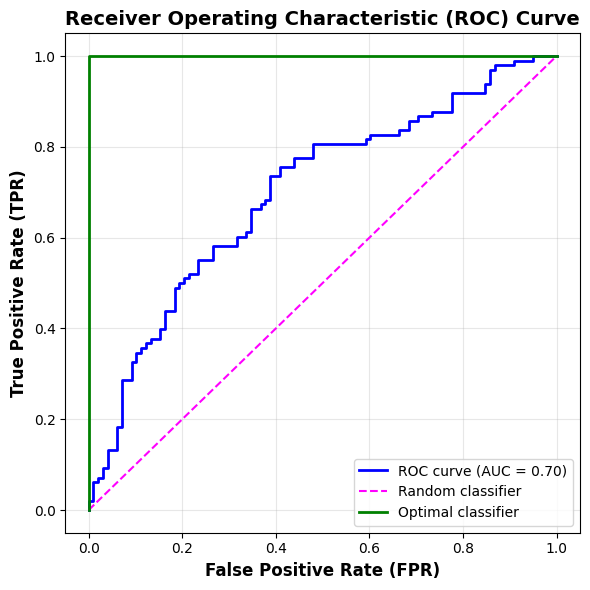

In [264]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(val_all_labels, val_all_outputs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='magenta', lw=1.5, linestyle='--', label='Random classifier')
plt.plot([0, 0, 1], [0, 1, 1], color='green', lw=2, label='Optimal classifier')

# Labels and title
plt.xlabel('False Positive Rate (FPR)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (TPR)', fontsize=12, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
